In [10]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')

In [11]:
# Step 2: Load and Explore the Dataset
column_names = ['letter'] + [f'feature_{i}' for i in range(1, 17)]
df = pd.read_csv('letter-recognition.data', header=None, names=column_names)

print('Dataset shape:', df.shape)
display(df.head())
print('\nMissing values:')
print(df.isnull().sum().sum())

Dataset shape: (20000, 17)


,letter,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10



Missing values:
0


In [12]:
# Step 3: Preprocess the Data
X = df.drop('letter', axis=1)
y = df['letter']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Number of classes:', len(label_encoder.classes_))
print('Classes:', label_encoder.classes_)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Number of classes: 26
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Train shape: (16000, 16) (16000, 26)
Test shape: (4000, 16) (4000, 26)


In [13]:
# Step 4: Build the Deep Neural Network Model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,194 (184.35 KB)

 Trainable params: 47,194 (184.35 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Step 5: Train the Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

Test Accuracy: 0.961

Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.98      0.98       158
           B       0.86      0.96      0.91       153
           C       0.96      0.97      0.97       147
           D       0.95      0.96      0.96       161
           E       0.88      0.99      0.93       154
           F       0.94      0.97      0.96       155
           G       0.95      0.92      0.93       155
           H       0.94      0.90      0.92       147
           I       0.99      0.91      0.95       151
           J       0.93      0.99      0.96       149
           K       0.95      0.96      0.95       148
           L       0.99      0.95      0.97       152
           M       0.99      0.99      0.99       158
           N       0.99      0.94      0.96       157
           O       0.97      0.95      0.96       150
           P       0.97      0.96      0.97       161
           Q       0.97      0.99   

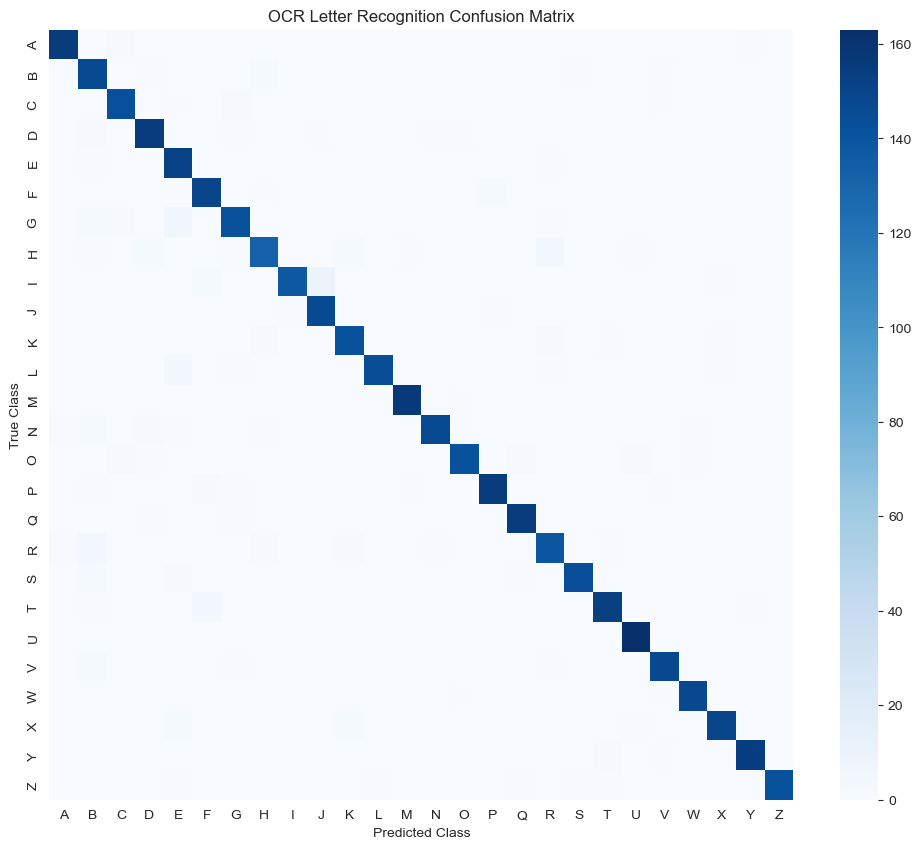

In [15]:
# Step 6: Evaluate Model Performance
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('Test Accuracy:', accuracy_score(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    cmap='Blues',
    cbar=True,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('OCR Letter Recognition Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [16]:
# Step 7: Make Predictions on Sample Test Data
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_probs = model.predict(X_test[sample_indices], verbose=0)
sample_preds = np.argmax(sample_probs, axis=1)
sample_confidences = np.max(sample_probs, axis=1)
sample_actual = np.argmax(y_test[sample_indices], axis=1)

for i in range(len(sample_indices)):
    actual_letter = label_encoder.inverse_transform([sample_actual[i]])[0]
    predicted_letter = label_encoder.inverse_transform([sample_preds[i]])[0]
    print(f'Sample {i + 1}: Actual = {actual_letter}, Predicted = {predicted_letter}, Confidence = {sample_confidences[i]:.4f}')

Sample 1: Actual = I, Predicted = I, Confidence = 0.8479
Sample 2: Actual = X, Predicted = X, Confidence = 0.9848
Sample 3: Actual = S, Predicted = S, Confidence = 0.9999
Sample 4: Actual = T, Predicted = T, Confidence = 0.7055
Sample 5: Actual = I, Predicted = I, Confidence = 0.8881


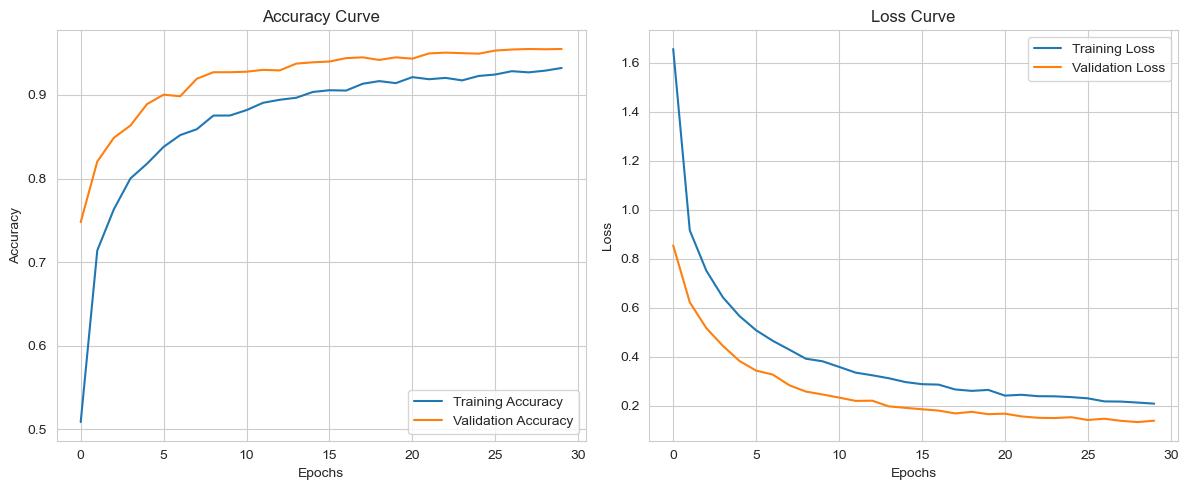

In [17]:
# Step 8: Visualize Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()